In [1]:
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns

In [2]:
sample_300 = np.load('/projects/b1042/GoyalLab/jaekj/KeepingScore/SCTAB_FINAL/datapoint_extraction/sample_300/sample_300.npz', allow_pickle=True)

In [3]:
cell_type_mapping = pd.read_parquet("/projects/b1042/GoyalLab/jaekj/KeepingScore/merlin_cxg_2023_05_15_sf-log1p/categorical_lookup/cell_type.parquet")
label_to_name = cell_type_mapping["label"].to_dict()

In [4]:
# Generate anndata object
X = sample_300['X']
y = sample_300['y']
adata = ad.AnnData(X)
adata.obs['label'] = y
adata.obs["cell_type"] = adata.obs["label"].map(label_to_name).fillna(adata.obs["label"].astype(str)).astype(str)

def clean_celltype_label(label):
    label = str(label)
    label = label.replace('\x07lpha', 'alpha')
    label = label.replace('\x08eta', 'beta')
    label = label.replace('\\alpha', 'alpha')
    label = label.replace('\\beta', 'beta')
    label = label.replace('\\gamma', 'gamma')
    label = label.replace('$', '')
    label = label.replace('{', '').replace('}', '')
    label = ' '.join(label.split())
    return label

adata.obs['cell_type_plot'] = adata.obs['cell_type'].map(clean_celltype_label).astype('category')

sc.pp.pca(adata, n_comps=min(50, adata.n_vars))
sc.pp.neighbors(adata, use_rep='X')
sc.tl.umap(adata, random_state=42)

palette = sns.color_palette('hls', adata.obs['cell_type_plot'].nunique())

/projects/b1042/GoyalLab/jaekj/python/scTAB_new/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/projects/b1042/GoyalLab/jaekj/python/scTAB_new/lib/python3.8/site-packages/anndata/_core/anndata.py:1228: FutureWarning: The `inplace` parameter in pandas.Categorical.reorder_categories is deprecated and will be removed in a future version. Reordering categories will always return a new Categorical object.
  c.reorder_categories(natsorted(c.categories), inplace=True)
... storing 'cell_type' as categorical


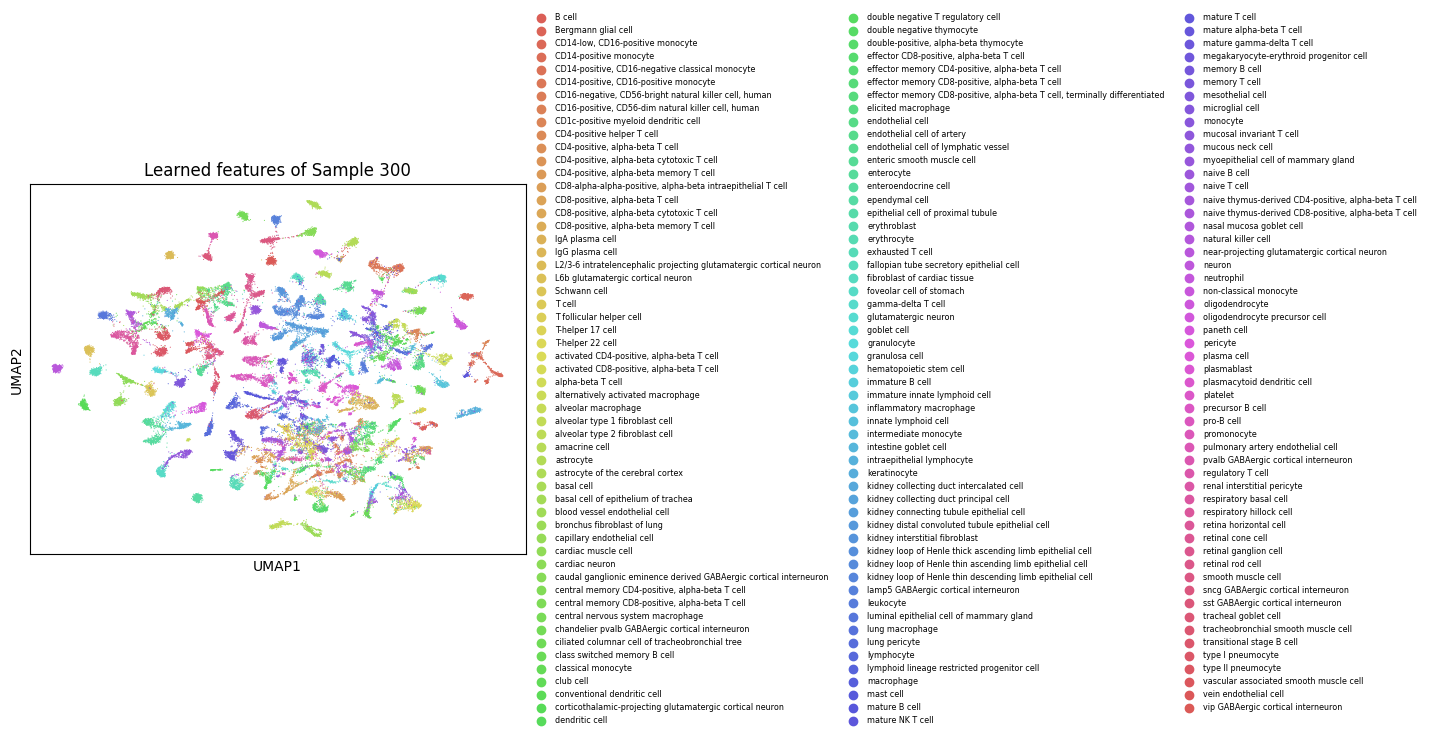

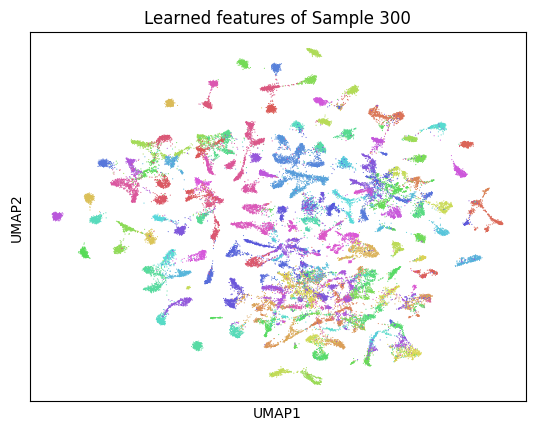

In [5]:
sc.pl.umap(
    adata,
    color='cell_type_plot',
    palette=palette,
    legend_fontsize='xx-small',
    ncols=1,
    title='Learned features of Sample 300',
    show=False,
)
plt.show()

sc.pl.umap(
    adata,
    color='cell_type_plot',
    palette=palette,
    legend_fontsize='xx-small',
    legend_loc=None,
    ncols=1,
    title='Learned features of Sample 300',
    show=False,
)
plt.show()

In [6]:
# ----------------------------
# Compute centroids in UMAP space
# ----------------------------
umap_coords = adata.obsm["X_umap"]

centroids = (
    pd.DataFrame(umap_coords, columns=["UMAP1", "UMAP2"])
    .assign(cell_type=adata.obs["cell_type_plot"].values)
    .groupby("cell_type")
    .mean()
)

# Map colors to each class (same as scanpy uses)
cell_types = adata.obs["cell_type_plot"].cat.categories
color_map = dict(zip(cell_types, palette))

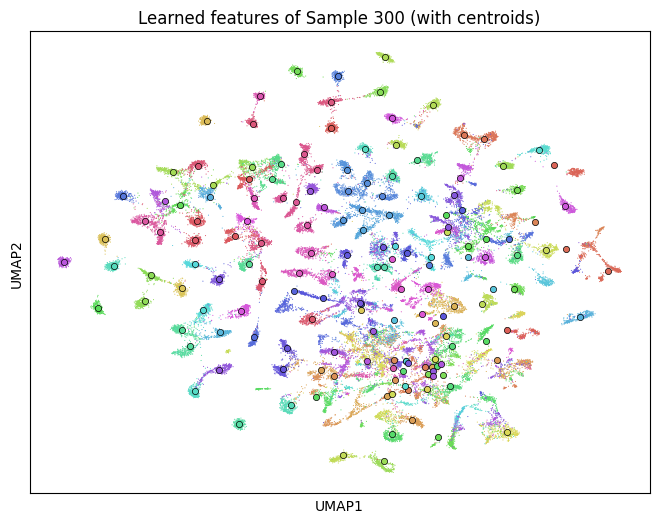

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

# Base UMAP
sc.pl.umap(
    adata,
    color='cell_type_plot',
    palette=palette,
    legend_loc=None,
    show=False,
    ax=ax
)

# Overlay centroids
for ct, row in centroids.iterrows():
    ax.scatter(
        row["UMAP1"],
        row["UMAP2"],
        color=color_map[ct],
        s=20,          # size of centroid dot
        edgecolor="black",
        linewidth=0.5,
        zorder=10       # make sure it's on top
    )

plt.title("Learned features of Sample 300 (with centroids)")
plt.show()

In [8]:
import plotly.io as pio
pio.renderers.default = "browser"

# UMAP coords
df = pd.DataFrame(adata.obsm["X_umap"], columns=["UMAP1", "UMAP2"])
df["cell_type"] = adata.obs["cell_type_plot"].values

# Centroids
centroids_df = centroids.reset_index().rename(columns={"cell_type": "cell_type"})
centroids_df["type"] = "centroid"
df["type"] = "cell"

In [9]:
color_map_plotly = {ct: f"rgb{tuple(int(255*x) for x in c)}"
                    for ct, c in zip(cell_types, palette)}

In [10]:
fig = px.scatter(
    df,
    x="UMAP1",
    y="UMAP2",
    color="cell_type",
    color_discrete_map=color_map_plotly,
    opacity=0.6,
    hover_data=["cell_type"]
)

# Add centroids as a second layer
fig.add_scatter(
    x=centroids_df["UMAP1"],
    y=centroids_df["UMAP2"],
    mode="markers",
    marker=dict(
        size=12,
        color=[color_map_plotly[ct] for ct in centroids_df["cell_type"]],
        line=dict(width=1, color="black"),
        symbol="diamond"
    ),
    text=centroids_df["cell_type"],
    name="centroids",
    hoverinfo="text"
)

fig.update_layout(
    title="UMAP with Cell Type Centroids (Interactive)",
    legend_title="Cell Type",
    width=900,
    height=700
)
fig.write_html("umap_interactive.html")
fig.show()

NameError: name 'px' is not defined